# SegFormer-B0 — BUSI Lezyon Segmentasyonu (Colab)

Uc mimarinin ilki. RTMDet-Ins ve YOLOv11-Seg instance segmentation yapiyor, bu model
semantic — ikili maske ile egitiliyor. Karsilastirmanin mimariyi olcmesi icin ortak
tutulanlar:

| Ortak | Nerede |
|---|---|
| Split (538/116/115), grup-aware, kopyasiz val/test | `veri/veri_manifest.csv` |
| Letterbox girdi hazirligi | asagidaki `letterbox_uygula` — RTMDet config'iyle ayni kural |
| Augmentasyon zinciri (`orta`) | `rtmdet_ins_busi.py` ALBU listesiyle birebir |
| Dice protokolu (orijinal cozunurluk, bos maske kirilimi) | `ortak/degerlendirme.py` |
| Sabit degerlendirme vakalari | `ortak/eval_cases.json` |

**Model secimi her epoch orijinal cozunurlukteki Dice ile yapiliyor** — raporlanan
metrik neyse secim de onunla. RTMDet'te bunu yapmamak pahaliya patlamisti: secim
`segm_mAP` uzerindendi ve o metrik bozuktu (PLAN.md hata 8).

In [1]:
!pip -q install transformers albumentations openpyxl

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import json, os, shutil, sys, time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import albumentations as A
from transformers import SegformerForSemanticSegmentation

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE, '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else '')

Mounted at /content/drive
Device: cuda | Tesla T4


## CONFIG

In [3]:
TOHUM = 44               # Faz 2: 42 / 43 / 44 ile uc kosu

GIRDI = 256              # RTMDet'in ana kosusuyla esit girdi butcesi.
                         # SegFormer cikti stride 4 -> maske izgarasi 64x64, tavan 0.9922
BATCH = 16
LR = 1e-4                # AdamW, transformer fine-tuning icin standart aralik
WEIGHT_DECAY = 0.01
WARMUP_ITER = 200        # RTMDet config'indeki LinearLR ile ayni uzunluk
MAX_EPOCH = 100          # 70 denendi ve geri alindi: MAX_EPOCH'u kisaltmak takvimi
                         # kirpmiyor, cosine'i yeniden olcekliyor. 70'lik kosuda
                         # RTMDet'in zirvesi ep28'e dusup 0.642 -> 0.621 oldu; kayip
                         # maske kalitesinden degil skor kalibrasyonundan geliyordu
AUG_SEVIYE = 'orta'      # 'hafif' | 'orta'
RESUME = False

# MODEL_KEY girdi ve augmentasyondan turetiliyor: ablasyon kosulari (384 girdi,
# hafif augmentasyon) ayni Drive klasorune yazip ana kosuyu ezmesin.
MODEL_KEY = f'segformer_b0_{GIRDI}_{AUG_SEVIYE}_s{TOHUM}'

# Maske kucultme interpolasyonu. cv2.INTER_NEAREST cikti pikselini floor ile
# esliyor ve maskeyi yarim piksel kaydiriyor; NEAREST_EXACT kaydirmiyor.
# Burada EXACT dogru secim cunku **bu pipeline'in iki ucu da merkez-dogru**:
# hedef EXACT ile kuculuyor, tahmin F.interpolate(align_corners=False) ile geri
# buyuyor. Onemli olan "her zaman EXACT" degil, girdi hazirligi ile geri
# olceklemenin ayni konvansiyonu kullanmasi -- RTMDet'te mmdet'in nearest bias'i
# kendi cikarim tarafindaki ters bias'i telafi ettigi icin orada NEAREST dogru
# secim cikti (PLAN.md hata 9). Varsayima guvenilmiyor: asagidaki "Hizalama
# kontrolu" bolumu bunu tahminler uzerinde olcuyor.
MASKE_INTERP = cv2.INTER_NEAREST_EXACT

PROJE = '/content/drive/MyDrive/real_time_segmentasyon'
VERI_KAYNAK = f'{PROJE}/Dataset_BUSI_with_GT'
VERI = '/content/dataset'                     # her epoch Drive'dan PNG okumak en yavas kisim olurdu

DRIVE_DIR = f'{PROJE}/{MODEL_KEY}'
LOCAL_DIR = f'/content/outputs/{MODEL_KEY}'
CKPT_DIR = f'{DRIVE_DIR}/checkpoints'
CASES_DIR = f'{DRIVE_DIR}/{MODEL_KEY}_cases'
for d in [DRIVE_DIR, LOCAL_DIR, CKPT_DIR, CASES_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

EXCEL_LOG = f'{DRIVE_DIR}/{MODEL_KEY}_log.xlsx'
CURVES_PNG = f'{DRIVE_DIR}/{MODEL_KEY}_curves.png'
VAL_ESIK_XLSX = f'{DRIVE_DIR}/{MODEL_KEY}_val_esik.xlsx'
TEST_XLSX = f'{DRIVE_DIR}/{MODEL_KEY}_test_summary.xlsx'
LAST_CKPT = f'{CKPT_DIR}/last.pt'
BEST_CKPT = f'{CKPT_DIR}/best.pt'

sys.path.insert(0, f'{PROJE}/ortak')
os.environ['RT_SEG_KOK'] = PROJE
os.environ['RT_SEG_VERI'] = VERI

print('MODEL_KEY:', MODEL_KEY, '| girdi', GIRDI, '| batch', BATCH, '| epoch', MAX_EPOCH)
print('Drive cikti:', DRIVE_DIR)


def mirror_to_local(drive_path):
    dst = Path(LOCAL_DIR) / Path(drive_path).name
    shutil.copy2(drive_path, dst)
    return str(dst)

MODEL_KEY: segformer_b0_256_orta_s44 | girdi 256 | batch 16 | epoch 100
Drive cikti: /content/drive/MyDrive/real_time_segmentasyon/segformer_b0_256_orta_s44


## On kosul: Colab makinesinde olmasi gereken dosyalar

VSCode'dan calisilsa bile **kernel Colab makinesinde**, dolayisiyla kodun okudugu
her sey Drive'da olmali. Notebook dosyasinin kendisi yerelde durabilir.

Eksik varsa `colab_yukle.zip` Drive'daki proje klasorune birakilir; asagidaki hucre
onu **yalnizca eksik dosyalar icin** acar, Drive'da zaten var olani ezmez.

In [4]:
import importlib
import zipfile

GEREKLI = [
    'ortak/degerlendirme.py', 'ortak/eval_cases.json',
    'veri/veri_manifest.csv',
]

eksik = [g for g in GEREKLI if not Path(f'{PROJE}/{g}').exists()]
if eksik:
    paket = Path(f'{PROJE}/colab_yukle.zip')
    if paket.exists():
        with zipfile.ZipFile(paket) as z:
            acilan = [a for a in z.namelist()
                      if not a.endswith('/') and not Path(f'{PROJE}/{a}').exists()]
            z.extractall(PROJE, members=acilan)
        print(f'{paket.name}: {len(acilan)} dosya acildi')
        eksik = [g for g in GEREKLI if not Path(f'{PROJE}/{g}').exists()]

if eksik:
    raise FileNotFoundError(
        'Drive\'da eksik dosyalar:\n  ' + '\n  '.join(eksik) +
        f'\n\nCozum: colab_yukle.zip dosyasini {PROJE}/ icine yukleyip bu hucreyi'
        ' tekrar calistirin (yerelde d:/mamografi/colab_yukle.zip).')

# Dosyalar calisma aninda olustugu icin sart: sys.path'e eklenen bir dizin
# modul bulunamadan taranmissa Python sonucu path_importer_cache'e yaziyor ve
# klasor sonradan dolsa bile yeniden bakmiyor.
importlib.invalidate_caches()

print('on kosullar tamam')
for g in GEREKLI:
    print('  ', g)

on kosullar tamam
   ortak/degerlendirme.py
   ortak/eval_cases.json
   veri/veri_manifest.csv


## Tekrarlanabilirlik

In [5]:
import random


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(TOHUM)

## Veri: Drive -> /content kopyasi

769 kucuk PNG'yi her epoch Drive uzerinden okumak egitimin en yavas kismi olurdu
(density projesinde ayni darbogaz `.npy` cache ile cozulmustu).

In [6]:
if not Path(VERI).exists():
    t0 = time.time()
    shutil.copytree(VERI_KAYNAK, VERI)
    print(f'veri kopyalandi: {time.time() - t0:.0f} sn')

import degerlendirme as dg   # ortak/degerlendirme.py

manifest = dg.manifest_oku()
print(manifest.groupby(['split', 'cls']).size().unstack(fill_value=0))
print('\ntoplam', len(manifest), '| bos maskeli', int((manifest.lesion_px == 0).sum()))

veri kopyalandi: 813 sn
cls    benign  malignant  normal
split                           
test       65         31      19
train     300        146      92
val        65         31      20

toplam 769 | bos maskeli 131


## Letterbox

RTMDet'te kare resize maske hizalamasini bozmustu (PLAN.md hata 6) ve girdi hazirligi
letterbox'a cevrilmisti. YOLOv11-Seg de letterbox kullaniyor. Ucunde ayni olmasi sart,
yoksa karsilastirma girdi hazirligini olcer.

Kural RTMDet config'iyle ayni: en-boy korunarak `GIRDI`'ye sigacak sekilde kucult
(`int(x*r + 0.5)`, mmcv `rescale_size` konvansiyonu), sonra sag-alta doldur
(goruntu 114, maske 0).

`letterbox_geri` tahmini orijinal cozunurluge tasiyor — degerlendirme orada yapiliyor.

In [7]:
def letterbox_olcu(h, w, girdi=GIRDI):
    r = min(girdi / h, girdi / w)
    return r, int(h * r + 0.5), int(w * r + 0.5)


def letterbox_uygula(img, mask=None, girdi=GIRDI):
    h, w = img.shape[:2]
    _, nh, nw = letterbox_olcu(h, w, girdi)
    im = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_LINEAR)
    out = np.full((girdi, girdi, 3), 114, np.uint8)
    out[:nh, :nw] = im
    if mask is None:
        return out
    mk = cv2.resize(mask, (nw, nh), interpolation=MASKE_INTERP)
    mout = np.zeros((girdi, girdi), np.uint8)
    mout[:nh, :nw] = mk
    return out, mout


def letterbox_geri(harita, h, w, girdi=GIRDI):
    """(girdi, girdi) tensor -> (h, w). Dolgu kirpilir, sonra orijinale buyutulur."""
    _, nh, nw = letterbox_olcu(h, w, girdi)
    kirp = harita[..., :nh, :nw]
    return F.interpolate(kirp[None, None], size=(h, w), mode='bilinear',
                         align_corners=False)[0, 0]


# Hizalama kontrolu **merkez mesafesiyle** yapiliyor, IoU ile degil: kucultup
# buyutmek maskeyi zaten kacinilmaz sekilde bozuyor, IoU bu kaybi geometri
# kaymasiymis gibi gosterir (PLAN.md hata 4'teki tuzagin aynisi). Merkez mesafesi
# interpolasyon kaybindan bagimsiz, kaymayi dogrudan olcer.
def _merkez(m):
    ys, xs = np.nonzero(m)
    return np.array([xs.mean(), ys.mean()])


_mes, _tavan = [], []
for _r in manifest[(manifest.split == 'val') & (manifest.lesion_px > 0)].itertuples():
    _gt = dg.gt_maskesi(_r)
    _h, _w = _gt.shape
    _, _nh, _nw = letterbox_olcu(_h, _w)
    _k = np.zeros((GIRDI, GIRDI), np.uint8)
    _k[:_nh, :_nw] = cv2.resize(_gt, (_nw, _nh), interpolation=MASKE_INTERP)
    _b = (letterbox_geri(torch.from_numpy(_k).float(), _h, _w) > 0.5).numpy()
    _bekl = (_merkez(_gt) + 0.5) * np.array([_nw / _w, _nh / _h]) - 0.5
    _mes.append(np.linalg.norm(_merkez(_k) - _bekl))
    _tavan.append(2 * np.logical_and(_b, _gt).sum() / (_b.sum() + _gt.sum()))

print(f'letterbox kaymasi (px, {GIRDI} uzayinda): medyan {np.median(_mes):.3f}  '
      f'max {np.max(_mes):.3f}')
print(f'temsil tavani (Dice, gidis-donus): medyan {np.median(_tavan):.4f}  '
      f'p5 {np.percentile(_tavan, 5):.4f}')
assert np.median(_mes) < 0.2, ('maske kuculturken kayiyor -- MASKE_INTERP '
                               'INTER_NEAREST ise beklenen budur (medyan ~0.69 px)')

letterbox kaymasi (px, 256 uzayinda): medyan 0.071  max 0.198
temsil tavani (Dice, gidis-donus): medyan 0.9915  p5 0.9776


## Dataset + augmentasyon

Zincir `rtmdet_ins_busi.py` icindeki ALBU listesiyle birebir ayni ve augmentasyon
**orijinal cozunurlukte** uygulanip letterbox en sona konuyor — RTMDet'te de sira boyle.

Goruntu `uint8` (0-255) okundugu icin `A.Normalize` varsayilan `max_pixel_value=255.0`
ile dogru (PLAN.md, density projesinin tersi).

In [8]:
ALBU = {
    'hafif': [
        A.HorizontalFlip(p=0.5),
        A.Affine(translate_percent=(-0.05, 0.05), scale=(0.9, 1.1), rotate=(-10, 10), p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.3),
    ],
    'orta': [
        A.HorizontalFlip(p=0.5),
        A.Affine(translate_percent=(-0.1, 0.1), scale=(0.85, 1.15), rotate=(-15, 15), p=0.7),
        A.ElasticTransform(alpha=30, sigma=6, p=0.25),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.RandomGamma(gamma_limit=(80, 120), p=0.3),
        A.MultiplicativeNoise(multiplier=(0.85, 1.15), elementwise=True, p=0.3),
        A.MotionBlur(blur_limit=7, p=0.2),
    ],
}[AUG_SEVIYE]

TRAIN_AUG = A.Compose(ALBU)
NORM = A.Normalize()          # max_pixel_value=255.0 varsayilani dogru


class BusiDataset(Dataset):
    def __init__(self, split, egitim):
        self.df = dg.manifest_oku(split)
        self.egitim = egitim

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = cv2.cvtColor(dg.gri_oku(dg.yol_coz(r.image_path)), cv2.COLOR_GRAY2BGR)
        mask = dg.gt_maskesi(r)
        if self.egitim:
            c = TRAIN_AUG(image=img, mask=mask)
            img, mask = c['image'], c['mask']
        h, w = img.shape[:2]
        img, mask = letterbox_uygula(img, mask)

        # Dolgu bolgesi kayba girmesin: piksellerin medyanda ~%16'si (en uc
        # en-boy oraninda %31) sabit gri dolgu ve arkaplan etiketli. BCE tum
        # pikselleri ortaladigi icin bu, gradyani seyreltiyordu. RTMDet'in
        # bolge tabanli maske kaybi dolguyu icermiyor -- maskeleyerek iki model
        # ayni sey uzerinde optimize ediliyor.
        _, nh, nw = letterbox_olcu(h, w)
        gecerli = np.zeros((GIRDI, GIRDI), np.float32)
        gecerli[:nh, :nw] = 1.0

        x = torch.from_numpy(NORM(image=img)['image']).permute(2, 0, 1).float()
        return (x, torch.from_numpy(mask).float()[None],
                torch.from_numpy(gecerli)[None])


train_ds, val_ds = BusiDataset('train', True), BusiDataset('val', False)
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2,
                      pin_memory=True, drop_last=True)
# Val loss icin: augmentasyon yok, karistirma yok -- olcum deterministik olmali
val_dl = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=2,
                    pin_memory=True)

_x, _y, _g = train_ds[0]
print('girdi', tuple(_x.shape), 'araligi [%.3f, %.3f]' % (_x.min(), _x.max()))
print('maske', tuple(_y.shape), 'benzersiz', torch.unique(_y).tolist())
print('gecerli piksel orani: %.3f' % _g.mean().item())
assert _x.shape == (3, GIRDI, GIRDI) and _y.shape == (1, GIRDI, GIRDI)
assert set(torch.unique(_y).tolist()) <= {0.0, 1.0}, 'maske ikili degil'
assert (_y * (1 - _g)).sum() == 0, 'dolgu bolgesinde lezyon var -- letterbox hatali'

girdi (3, 256, 256) araligi [-2.118, 2.640]
maske (1, 256, 256) benzersiz [0.0, 1.0]
gecerli piksel orani: 0.840


## Model

`nvidia/mit-b0` ImageNet on-egitimli encoder + taze decode head. Tek kanal logit
(`num_labels=1`) + sigmoid: cikti dogrudan "skor haritasi" oluyor ve ortak
degerlendirme protokolune oldugu gibi giriyor.

Decode head logitleri girdi/4'te uretiyor (stride 4) — PLAN.md'deki tavan analizi
bu varsayimla yapilmisti, burada dogrulaniyor.

In [9]:
model = SegformerForSemanticSegmentation.from_pretrained(
    'nvidia/mit-b0', num_labels=1, ignore_mismatched_sizes=True).to(DEVICE)

_p = sum(p.numel() for p in model.parameters())
with torch.no_grad():
    _l = model(pixel_values=torch.zeros(1, 3, GIRDI, GIRDI, device=DEVICE)).logits
print(f'parametre: {_p/1e6:.2f} M | logit izgarasi: {tuple(_l.shape[-2:])} '
      f'(stride {GIRDI // _l.shape[-1]})')
assert _l.shape[-1] == GIRDI // 4, 'cikti stride 4 bekleniyordu'


def logit_uret(x):
    """Logitleri girdi cozunurlugune buyutur. Buyutme logit uzerinde (olasilikta degil)."""
    l = model(pixel_values=x).logits
    return F.interpolate(l, size=(GIRDI, GIRDI), mode='bilinear', align_corners=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/70.0k [00:00<?, ?B/s]

[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `1000`.


pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 14.4MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.weight                                       | UNEXPECTED | 
classifier.bias                                         | UNEXPECTED | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_fuse.weight                          | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.running_var                      | MISSING    | 
decode_head.batch_norm.weight                           | MISSING    | 
decode_head.classifier.bias                             | MISSING    | 
decode_head.batch_norm.bias                             | MISSING    | 
decode_head.batch_norm.num_batches_tracked              | MISSING    | 
decode_head.classifier.weight                           

model.safetensors: reconstructing file:   0%|          |  0.00B / 14.3MB            

model.safetensors: downloading bytes:           |  0.00B            

parametre: 3.71 M | logit izgarasi: (64, 64) (stride 4)


## Kayip ve metrikler

Dice + BCE. Bos maskeli 92 egitim goruntusu bilerek veri setinde (negatif ornek);
Dice teriminde GT ve tahmin ikisi de bosken smooth sayesinde kayip 0 oluyor,
ayrica cezalandirilmiyor.

Metrikler goruntu basina manuel TP/FP/FN uzerinden — `ortak/degerlendirme.py` ile
ayni tanim (ikili durumda f1 = dice).

In [10]:
def dice_bce_loss(logits, hedef, gecerli, smooth=1.0):
    """Dice + BCE, letterbox dolgusu haric.

    `gecerli` dolgu disindaki bolgeyi isaretliyor. Dolgu sabit gri ve arkaplan
    etiketli; kayba katmak modelin zaten bildigi bir seyi ogrenmesine ayrilan
    gradyan demek.
    """
    bce_pik = F.binary_cross_entropy_with_logits(logits, hedef, reduction='none')
    bce = (bce_pik * gecerli).sum() / gecerli.sum().clamp(min=1)

    p = torch.sigmoid(logits) * gecerli
    h = hedef * gecerli
    kesisim = (p * h).sum(dim=(1, 2, 3))
    toplam = p.sum(dim=(1, 2, 3)) + h.sum(dim=(1, 2, 3))
    dice = (2 * kesisim + smooth) / (toplam + smooth)

    # Dice terimi yalnizca **lezyonlu** goruntulerde. Bos maskeli goruntude
    # (egitim setinin %17'si) tahmin neredeyse mukemmelken bile bu terim 0.7
    # veriyordu: smooth=1, ~54 bin gecerli pikselde biriken minik olasiliklarin
    # yaninda kucuk kaliyor ve payda siziyor. Kayip degeri ayrimci degil, yalnizca
    # "daha emin ol" baskisi -- o isi BCE zaten dogru olcekle yapiyor. Ayrica
    # degerlendirme kuralimiz "GT bos + tahmin bos = Dice 1" diyor; kaybin da
    # ayni konvansiyonu izlemesi gerekiyor.
    dolu = (h.sum(dim=(1, 2, 3)) > 0).float()
    dice_kaybi = ((1 - dice) * dolu).sum() / dolu.sum().clamp(min=1)
    return bce + dice_kaybi

## Orijinal cozunurlukte skor haritasi

Degerlendirmenin tamami bu fonksiyondan geciyor: letterbox geri alinir, harita
orijinal boyuta tasinir. Egitim sirasindaki val olcumu de, final esik taramasi da
ayni yolu kullaniyor — raporlanan metrik ile secim metrigi ayrismasin diye.

In [11]:
@torch.no_grad()
def skor_haritasi(satir):
    img = cv2.cvtColor(dg.gri_oku(dg.yol_coz(satir.image_path)), cv2.COLOR_GRAY2BGR)
    h, w = img.shape[:2]
    x = torch.from_numpy(NORM(image=letterbox_uygula(img))['image'])
    x = x.permute(2, 0, 1)[None].float().to(DEVICE)
    logit = logit_uret(x)[0, 0]
    return torch.sigmoid(letterbox_geri(logit, h, w)).cpu().numpy()


# GT maskeleri her epoch yeniden okunmasin (116 PNG x 100 epoch)
GT_VAL = {r.case_id: dg.gt_maskesi(r) for r in val_ds.df.itertuples()}
IZLEME_ESIKLERI = (0.3, 0.4, 0.5, 0.6, 0.7)


@torch.no_grad()
def val_dice(esikler=IZLEME_ESIKLERI):
    """Epoch basina izleme + model secimi. Olcut final raporlananla ayni.

    Sabit 0.5'te olcup secim yapmak, sonra raporu taranmis esikte vermek
    RTMDet'teki hatanin aynisi olurdu: orada secim `segm_mAP` uzerindendi ve o
    metrik bozuk cikinca yanlis checkpoint secilmisti (PLAN.md hata 8). Burada
    hem esik taraniyor hem olcut `dice_tum` -- `dg.en_iyi_esik` ile ayni.

    Skor haritasi goruntu basina bir kez uretilip tum esiklerde kullaniliyor,
    yani tarama neredeyse bedava.
    """
    model.eval()
    haritalar = [(r, skor_haritasi(r)) for r in val_ds.df.itertuples()]
    model.train()

    # Val kaybi: egitimdekiyle **ayni fonksiyon, ayni uzay** (letterbox'li 256,
    # dolgu maskeli). Farkli bir sey olcup "val loss" demek yaniltici olurdu.
    kayip_toplam, kayip_sayac = 0.0, 0
    with torch.no_grad():
        model.eval()
        for x, y, g in val_dl:
            x, y, g = (t.to(DEVICE, non_blocking=True) for t in (x, y, g))
            kayip_toplam += dice_bce_loss(logit_uret(x), y, g).item()
            kayip_sayac += 1
        model.train()
    val_kayip = kayip_toplam / max(kayip_sayac, 1)

    en_iyi = None
    for e in esikler:
        lez, bos = [], []
        for r, harita in haritalar:
            m = dg.metrikler(harita >= e, GT_VAL[r.case_id])
            (bos if r.lesion_px == 0 else lez).append(m)
        L, B = pd.DataFrame(lez), pd.DataFrame(bos)
        kayit = dict(
            esik=e, dice_tum=(L.dice.sum() + B.dice.sum()) / (len(L) + len(B)),
            dice=L.dice.mean(), iou=L.iou.mean(), precision=L.precision.mean(),
            recall=L.recall.mean(), bos_dogru=int((B.dice == 1.0).sum()), bos_n=len(B))
        if en_iyi is None or kayit['dice_tum'] > en_iyi['dice_tum']:
            en_iyi = kayit
    en_iyi['val_kayip'] = val_kayip
    return en_iyi

## Excel log ve egriler

In [12]:
SCHEMA = ['epoch', 'train_loss', 'val_kayip', 'dice_tum', 'esik', 'dice', 'iou',
          'precision', 'recall', 'bos_dogru', 'bos_n', 'lr', 'epoch_sn']


def append_epoch_row(excel_path, row, resume_epoch=None):
    if os.path.exists(excel_path):
        df = pd.read_excel(excel_path)
        if resume_epoch is not None:
            df = df[df['epoch'] < resume_epoch]
        rows = df.to_dict('records')
    else:
        rows = []
    rows.append({k: row.get(k) for k in SCHEMA})
    pd.DataFrame(rows)[SCHEMA].to_excel(excel_path, index=False)
    return len(rows)


def plot_training_curves(excel_path, out_path, ad):
    df = pd.read_excel(excel_path)
    fig, ax = plt.subplots(2, 3, figsize=(18, 9))

    a = ax[0, 0]
    a.plot(df.epoch, df.train_loss, marker='o', ms=3, label='train')
    if 'val_kayip' in df and df.val_kayip.notna().any():
        a.plot(df.epoch, df.val_kayip, marker='o', ms=3, ls='--', label='val')
        a.legend(fontsize=8)
    a.set_title('Kayip (Dice+BCE, dolgu haric)'); a.set_xlabel('epoch'); a.grid(alpha=0.3)

    for a, k, t, c in [(ax[0, 1], 'dice_tum', 'Dice (tum, secim olcutu)', 'tab:green'),
                       (ax[0, 2], 'iou', 'IoU (lezyonlu)', 'tab:purple'),
                       (ax[1, 0], 'precision', 'Precision', 'tab:orange'),
                       (ax[1, 1], 'recall', 'Recall', 'tab:red')]:
        a.plot(df.epoch, df[k], marker='o', ms=3, color=c)
        a.set_ylim(0, 1); a.set_title(t); a.set_xlabel('epoch'); a.grid(alpha=0.3)
    i = int(df.dice_tum.idxmax())
    ax[0, 1].axvline(df.epoch[i], ls='--', lw=1, color='k')
    ax[0, 1].annotate(f'zirve ep{int(df.epoch[i])}\n{df.dice_tum[i]:.3f}',
                      (df.epoch[i], df.dice_tum[i]), textcoords='offset points',
                      xytext=(8, -20), fontsize=9)

    a = ax[1, 2]
    a.plot(df.epoch, df.lr, color='tab:brown')
    a.set_yscale('log'); a.set_title('Learning rate'); a.set_xlabel('epoch')
    a.grid(alpha=0.3, which='both')

    plt.suptitle(f'{ad}  ({len(df)} epoch)  — F1 = Dice: ikili segmentasyonda ozdes',
                 fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()

## Checkpoint / resume

In [13]:
def save_checkpoint(path, epoch, best_dice, epochs_without_improve=0):
    torch.save({
        'model': model.state_dict(), 'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(), 'epoch': epoch, 'best_dice': best_dice,
        'epochs_without_improve': epochs_without_improve,
        'torch_rng_state': torch.get_rng_state(),
        'numpy_rng_state': np.random.get_state(),
        'cfg': dict(girdi=GIRDI, batch=BATCH, lr=LR, aug=AUG_SEVIYE, seed=TOHUM),
    }, path)


def find_resumable_checkpoint():
    # density projesindeki ayni koruma: last.pt icinde epoch/optimizer yoksa
    # resume sessizce sifirdan baslayabilir. Once dogrula, yoksa acikca hata ver.
    if not os.path.exists(LAST_CKPT):
        raise FileNotFoundError(f'Resume edilebilir checkpoint yok: {LAST_CKPT}')
    ckpt = torch.load(LAST_CKPT, map_location=DEVICE, weights_only=False)
    for k in ('epoch', 'optimizer', 'scheduler', 'model'):
        if k not in ckpt:
            raise RuntimeError(f'{LAST_CKPT} eksik/bozuk ({k} yok) -- resume edilemez.')
    return ckpt


def restore_checkpoint(ckpt):
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    torch.set_rng_state(ckpt['torch_rng_state'].cpu())
    np.random.set_state(ckpt['numpy_rng_state'])
    return ckpt['epoch'], ckpt['best_dice'], ckpt.get('epochs_without_improve', 0)

## Egitim dongusu

LR takvimi RTMDet ile ayni sekilde: kisa lineer warmup, sonra ikinci yaridan
itibaren cosine ile `0.05 * LR`'ye iniyor.

In [14]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
adim_basina = len(train_dl)
toplam_adim = adim_basina * MAX_EPOCH
cosine_basi = adim_basina * (MAX_EPOCH // 2)


def lr_carpani(adim):
    if adim < WARMUP_ITER:
        return 1e-3 + (1 - 1e-3) * adim / WARMUP_ITER
    if adim < cosine_basi:
        return 1.0
    ilerleme = (adim - cosine_basi) / max(toplam_adim - cosine_basi, 1)
    return 0.05 + 0.95 * 0.5 * (1 + np.cos(np.pi * ilerleme))


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_carpani)


def train_one_epoch():
    model.train()
    toplam = 0.0
    for x, y, g in train_dl:
        x, y, g = (t.to(DEVICE, non_blocking=True) for t in (x, y, g))
        optimizer.zero_grad(set_to_none=True)
        kayip = dice_bce_loss(logit_uret(x), y, g)
        kayip.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        toplam += kayip.item()
    return toplam / len(train_dl)

In [15]:
start_epoch, best_dice, kotu = 0, -1.0, 0
if RESUME:
    start_epoch, best_dice, kotu = restore_checkpoint(find_resumable_checkpoint())
    print(f'resume: epoch {start_epoch}, best_dice {best_dice:.4f}')

for epoch in range(start_epoch, MAX_EPOCH):
    t0 = time.time()
    kayip = train_one_epoch()
    m = val_dice()
    sure = time.time() - t0

    append_epoch_row(EXCEL_LOG, dict(
        epoch=epoch + 1, train_loss=round(kayip, 5),
        val_kayip=round(m['val_kayip'], 5),
        dice_tum=round(m['dice_tum'], 5), esik=m['esik'], dice=round(m['dice'], 5),
        iou=round(m['iou'], 5), precision=round(m['precision'], 5),
        recall=round(m['recall'], 5), bos_dogru=m['bos_dogru'], bos_n=m['bos_n'],
        lr=optimizer.param_groups[0]['lr'], epoch_sn=round(sure, 1)),
        resume_epoch=epoch + 1 if epoch == start_epoch and RESUME else None)

    save_checkpoint(LAST_CKPT, epoch + 1, best_dice, kotu)
    yildiz = ''
    if m['dice_tum'] > best_dice:
        best_dice, kotu, yildiz = m['dice_tum'], 0, '  *'
        save_checkpoint(BEST_CKPT, epoch + 1, best_dice, kotu)
    else:
        kotu += 1
    print(f"ep {epoch+1:3d}/{MAX_EPOCH}  kayip {kayip:.4f}/{m['val_kayip']:.4f}  "
          f"dice_tum {m['dice_tum']:.4f} (esik {m['esik']})  "
          f"lezyonlu {m['dice']:.4f}  bos {m['bos_dogru']}/{m['bos_n']}  "
          f"{sure:.0f}sn{yildiz}",
          flush=True)

mirror_to_local(EXCEL_LOG)
print('\nen iyi val Dice (tum, taranmis esik):', round(best_dice, 4))

ep   1/100  kayip 1.5140/1.2396  dice_tum 0.2391 (esik 0.5)  lezyonlu 0.2889  bos 0/20  21sn  *
ep   2/100  kayip 1.3230/1.0387  dice_tum 0.5387 (esik 0.7)  lezyonlu 0.4843  bos 16/20  17sn  *
ep   3/100  kayip 1.1313/0.8940  dice_tum 0.5311 (esik 0.7)  lezyonlu 0.5689  bos 7/20  18sn
ep   4/100  kayip 1.0317/0.7946  dice_tum 0.5426 (esik 0.7)  lezyonlu 0.6140  bos 4/20  18sn  *
ep   5/100  kayip 0.9607/0.7136  dice_tum 0.6301 (esik 0.7)  lezyonlu 0.6260  bos 13/20  20sn  *
ep   6/100  kayip 0.8891/0.6725  dice_tum 0.6894 (esik 0.7)  lezyonlu 0.6455  bos 18/20  19sn  *
ep   7/100  kayip 0.7887/0.5962  dice_tum 0.7378 (esik 0.7)  lezyonlu 0.7040  bos 18/20  18sn  *
ep   8/100  kayip 0.7108/0.5095  dice_tum 0.7153 (esik 0.6)  lezyonlu 0.7081  bos 15/20  20sn
ep   9/100  kayip 0.6340/0.4610  dice_tum 0.7054 (esik 0.7)  lezyonlu 0.7273  bos 12/20  17sn
ep  10/100  kayip 0.5883/0.4588  dice_tum 0.7010 (esik 0.7)  lezyonlu 0.7116  bos 13/20  18sn
ep  11/100  kayip 0.5452/0.4135  dice_tum 0.7

## Val esik taramasi

Esik **val'de** seciliyor. Test'e sabit uygulanacak — test'e bakarak esik ayarlamak
sizinti olur (PLAN.md).

In [16]:
restore = torch.load(BEST_CKPT, map_location=DEVICE, weights_only=False)
model.load_state_dict(restore['model'])
model.eval()
print('best.pt epoch', restore['epoch'])

gb_val = dg.goruntu_basina(skor_haritasi, 'val')
tablo_val = dg.esik_tablosu(gb_val)
ESIK = dg.en_iyi_esik(tablo_val)

print(tablo_val.to_string(index=False))
print('\nsecilen esik:', ESIK)
print('\nlezyon boyutu kirilimi:')
print(dg.boyut_kirilimi(gb_val, ESIK).to_string(index=False))

with pd.ExcelWriter(VAL_ESIK_XLSX) as w:
    tablo_val.to_excel(w, sheet_name='esik_taramasi', index=False)
    dg.boyut_kirilimi(gb_val, ESIK).to_excel(w, sheet_name='boyut', index=False)
    gb_val.to_excel(w, sheet_name='goruntu_basina', index=False)
mirror_to_local(VAL_ESIK_XLSX)

best.pt epoch 68
 esik  dice_tum  dice_lezyonlu  iou_lezyonlu  precision_lezyonlu  recall_lezyonlu  bos_dogru  bos_toplam
 0.01    0.6341         0.7662        0.6552              0.7039           0.9115          0          20
 0.02    0.6719         0.7806        0.6764              0.7270           0.8957          3          20
 0.05    0.7342         0.7934        0.6968              0.7646           0.8751          9          20
 0.10    0.7725         0.7980        0.7064              0.7886           0.8574         13          20
 0.15    0.7907         0.7992        0.7102              0.8002           0.8458         15          20
 0.20    0.7997         0.7997        0.7125              0.8090           0.8367         16          20
 0.30    0.8077         0.7989        0.7137              0.8214           0.8219         17          20
 0.40    0.8235         0.7971        0.7130              0.8302           0.8096         19          20
 0.50    0.8214         0.7946        

'/content/outputs/segformer_b0_256_orta_s44/segformer_b0_256_orta_s44_val_esik.xlsx'

## Hizalama kontrolu

Tahmini kaydirinca Dice artiyor mu? Girdi hazirligi ile cikarim geri-olceklemesi
ayni piksel-merkezi konvansiyonunu kullanmiyorsa tahmin sistematik kayar ve zirve
(0, 0) disinda cikar.

RTMDet'te bu test pahali bir varsayimi cururtmustu (PLAN.md hata 9): teorik olarak
"dogru" olan on isleme aslinda hizalamayi bozuyordu. **Zirve (0,0)'da degilse
on isleme bozuk demektir** -- sonuclari raporlamadan once orasi duzeltilmeli.

In [17]:
kaydirma = dg.kaydirma_taramasi(skor_haritasi, 'val', esik=ESIK)
print(kaydirma.to_string())

# Duz bir yuzeyde argmax gurultudur; anlamli olan kaydirmayla kazanilan Dice
print()
for k, v in dg.hizalama_ozeti(kaydirma).items():
    print(f'  {k}: {v}')

dx      -2      -1       0       1       2
dy                                        
-2  0.7881  0.7904  0.7918  0.7923  0.7920
-1  0.7920  0.7942  0.7955  0.7959  0.7955
 0  0.7938  0.7959  0.7971  0.7974  0.7968
 1  0.7932  0.7953  0.7965  0.7967  0.7960
 2  0.7904  0.7924  0.7935  0.7937  0.7930

  dy: 0
  dx: 1
  merkez: 0.7971
  en_iyi: 0.7974
  kazanc: 0.0003
  kenar: False
  durum: hizalama tamam (kaydirma kazanci 0.0003 < 0.003)


## Test degerlendirmesi — esik val'den sabit

In [18]:
gb_test = dg.goruntu_basina(skor_haritasi, 'test', esikler=(ESIK,))
tablo_test = dg.esik_tablosu(gb_test)
print(tablo_test.to_string(index=False))
print('\nlezyon boyutu kirilimi:')
print(dg.boyut_kirilimi(gb_test, ESIK).to_string(index=False))

with pd.ExcelWriter(TEST_XLSX) as w:
    tablo_test.to_excel(w, sheet_name='ozet', index=False)
    dg.boyut_kirilimi(gb_test, ESIK).to_excel(w, sheet_name='boyut', index=False)
    gb_test.to_excel(w, sheet_name='goruntu_basina', index=False)
mirror_to_local(TEST_XLSX)

 esik  dice_tum  dice_lezyonlu  iou_lezyonlu  precision_lezyonlu  recall_lezyonlu  bos_dogru  bos_toplam
  0.4    0.7607         0.7341        0.6501              0.7633           0.7601         17          19

lezyon boyutu kirilimi:
   kova  n   dice    iou
    <80 16 0.7853 0.7139
 80-140 28 0.8335 0.7465
140-220 29 0.6605 0.5764
   >220 23 0.6705 0.5815


'/content/outputs/segformer_b0_256_orta_s44/segformer_b0_256_orta_s44_test_summary.xlsx'

## Egitim egrileri

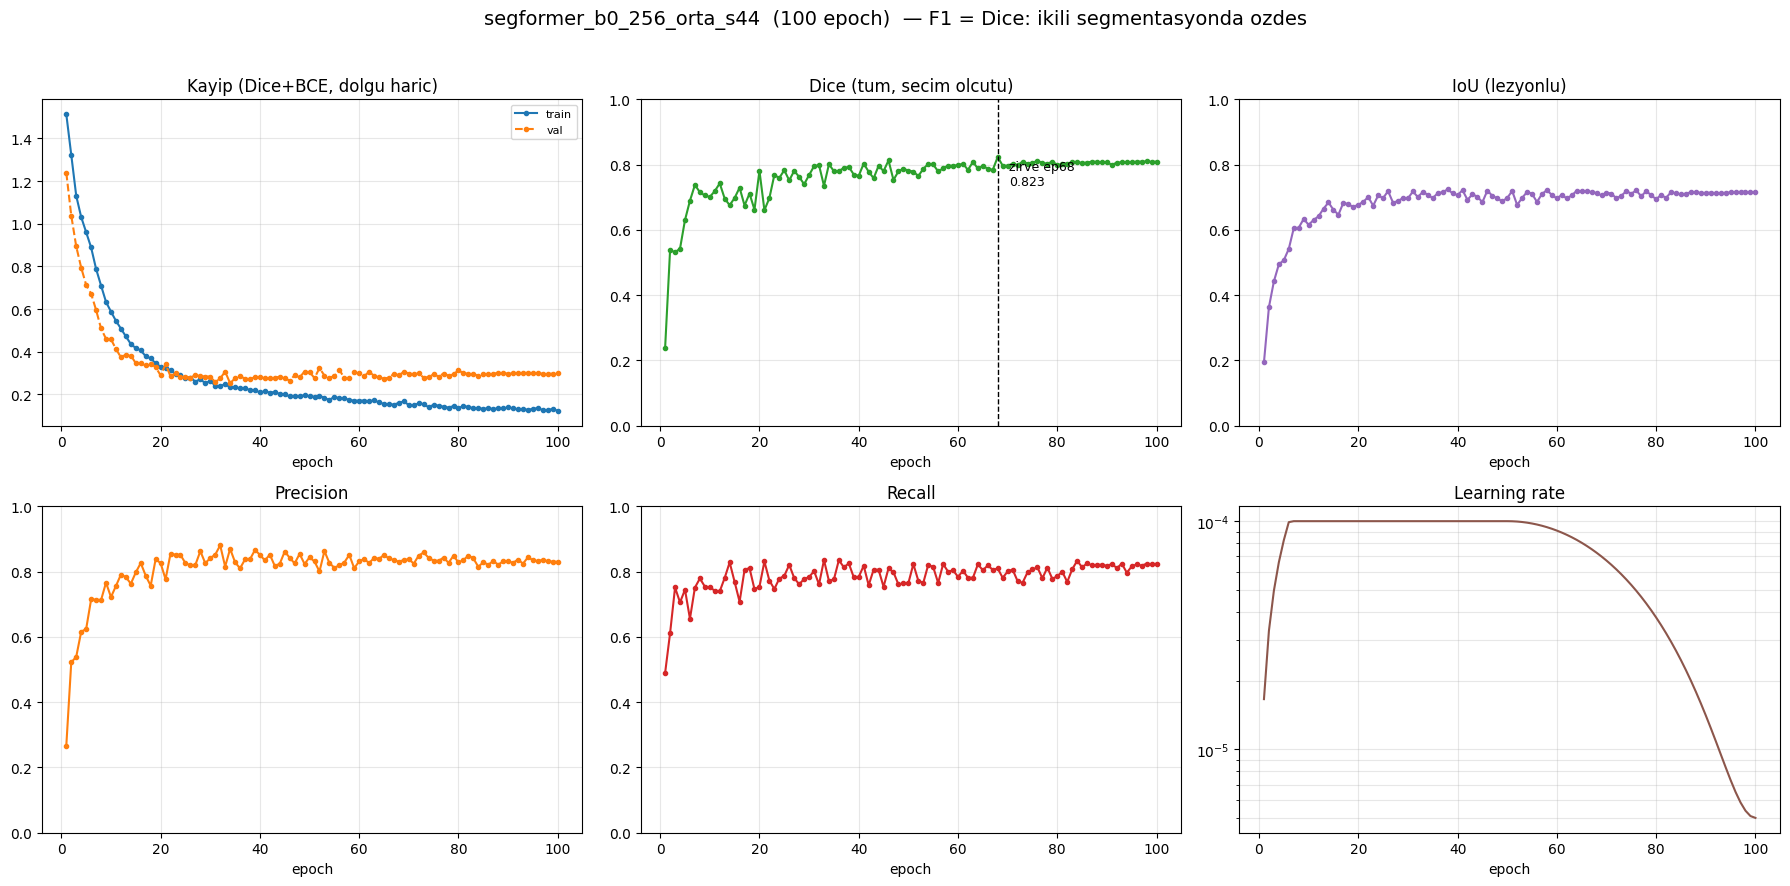

'/content/outputs/segformer_b0_256_orta_s44/segformer_b0_256_orta_s44_curves.png'

In [19]:
plot_training_curves(EXCEL_LOG, CURVES_PNG, MODEL_KEY)
mirror_to_local(CURVES_PNG)

## Sabit degerlendirme vakalari

`ortak/eval_cases.json` uc modelde ayni — her model kendi iyi ornegini secerse
gorsel karsilastirma hicbir sey soylemez.

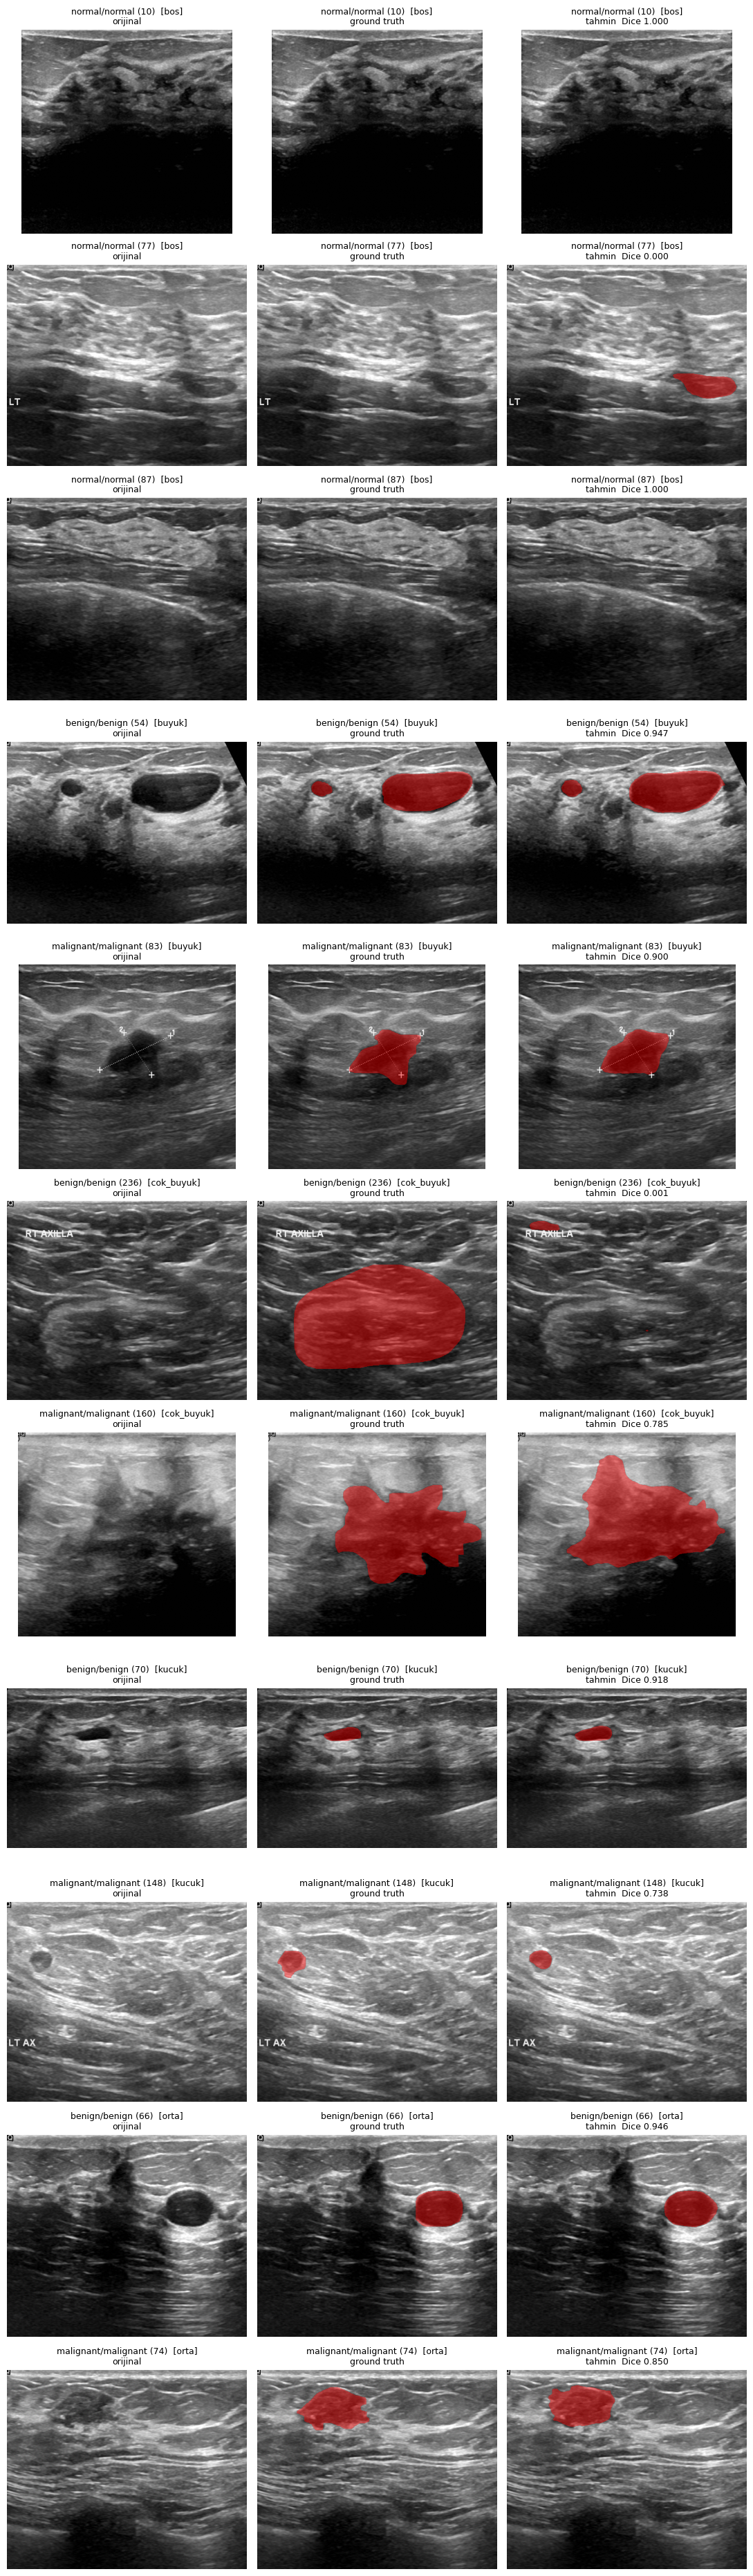

kaydedildi: /content/drive/MyDrive/real_time_segmentasyon/segformer_b0_256_orta_s44/segformer_b0_256_orta_s44_cases/segformer_b0_256_orta_s44_vakalar.png


In [20]:
vakalar = json.loads(Path(f'{PROJE}/ortak/eval_cases.json').read_text(encoding='utf-8'))['vakalar']
lut = {r.case_id: r for r in dg.manifest_oku().itertuples()}

fig, ax = plt.subplots(len(vakalar), 3, figsize=(11, 3.4 * len(vakalar)))
for i, v in enumerate(vakalar):
    r = lut[v['case_id']]
    img = dg.gri_oku(dg.yol_coz(r.image_path))
    gt = dg.gt_maskesi(r)
    pred = skor_haritasi(r) >= ESIK
    d = dg.metrikler(pred, gt)['dice']

    for j, (g, t) in enumerate([(img, 'orijinal'), (gt, 'ground truth'), (pred, f'tahmin  Dice {d:.3f}')]):
        ax[i, j].imshow(img, cmap='gray')
        if j:
            ax[i, j].imshow(np.ma.masked_where(g == 0, g), cmap='autumn', alpha=0.45)
        ax[i, j].set_title(f"{v['case_id']}  [{v['kova']}]\n{t}", fontsize=9)
        ax[i, j].axis('off')

plt.tight_layout()
png = f'{CASES_DIR}/{MODEL_KEY}_vakalar.png'
plt.savefig(png, dpi=130, bbox_inches='tight')
plt.show()
print('kaydedildi:', png)